In [1]:
import numpy as np
import pandas as pd
from utils import plot_training_metrics, plot_training_comparison, distribution_comparison, reward_comparison, plot_economic_metrics
from environment import agentDLVEnvV1
import os
import shutil
import random
import torch
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.callbacks import CallbackList
from ReLuExtractor import ReLUFeatureExtractor

In [2]:
df = pd.read_csv('island_data.csv')
timestamp = df['timestamp'].values
nav = df['nav'].values
nect_price = pd.read_csv('nect_honey_price.csv')['price'].values
vol_token_price = pd.read_csv('wbtc_honey_price.csv')['price'].values
volatile_part = df['wbtc_frac'].values

SCALE = 6.5*10**7
LEARNING_EPOCHS = 2*1024*300 #default 200
TARGET_LEVERAGE = 2
nav = nav/SCALE
vol_token_price = vol_token_price/SCALE

nav_calm = nav[:3720]
nav_vol = nav[3720:]
volatile_part_calm = volatile_part[:3720]
volatile_part_vol = volatile_part[3720:]
nect_price_calm = nect_price[:3720]
nect_price_vol = nect_price[3720:]
vol_token_price_calm = vol_token_price[:3720]
vol_token_price_vol = vol_token_price[3720:]

nav_calm_train = nav_calm[:int(0.6*len(nav_calm))]
nav_calm_test = nav_calm[int(0.6*len(nav_calm)):]
nav_vol_train = nav_vol[int(0.4*len(nav_vol)):]
nav_vol_test = nav_vol[:int(0.4*len(nav_vol))]

volatile_part_calm_train = volatile_part_calm[:int(0.6*len(volatile_part_calm))]
volatile_part_calm_test = volatile_part_calm[int(0.6*len(volatile_part_calm)):]
volatile_part_vol_train = volatile_part_vol[int(0.4*len(volatile_part_vol)):]
volatile_part_vol_test = volatile_part_vol[:int(0.4*len(volatile_part_vol))]

nect_price_calm_train = nect_price_calm[:int(0.6*len(nect_price_calm))]
nect_price_calm_test = nect_price_calm[int(0.6*len(nect_price_calm)):]
nect_price_vol_train = nect_price_vol[int(0.4*len(volatile_part_vol)):]
nect_price_vol_test = nect_price_vol[:int(0.4*len(volatile_part_vol))]

vol_token_price_calm_train = vol_token_price_calm[:int(0.6*len(nav_calm))]
vol_token_price_calm_test = vol_token_price_calm[int(0.6*len(nav_calm)):]
vol_token_price_vol_train = vol_token_price_vol[int(0.4*len(nav_vol)):]
vol_token_price_vol_test = vol_token_price_vol[:int(0.4*len(nav_vol))]

In [3]:
def naiveAgent(obs, target_leverage = 2, max_step = 0.15, deviation = 0.01):

    nect = obs[0]
    leverage = obs[3] + target_leverage
    colateral_value = obs[1]
    volatile_part_value = obs[2]

    if abs(leverage - target_leverage)/target_leverage<=deviation:
        return 0
    else: 
        return 1

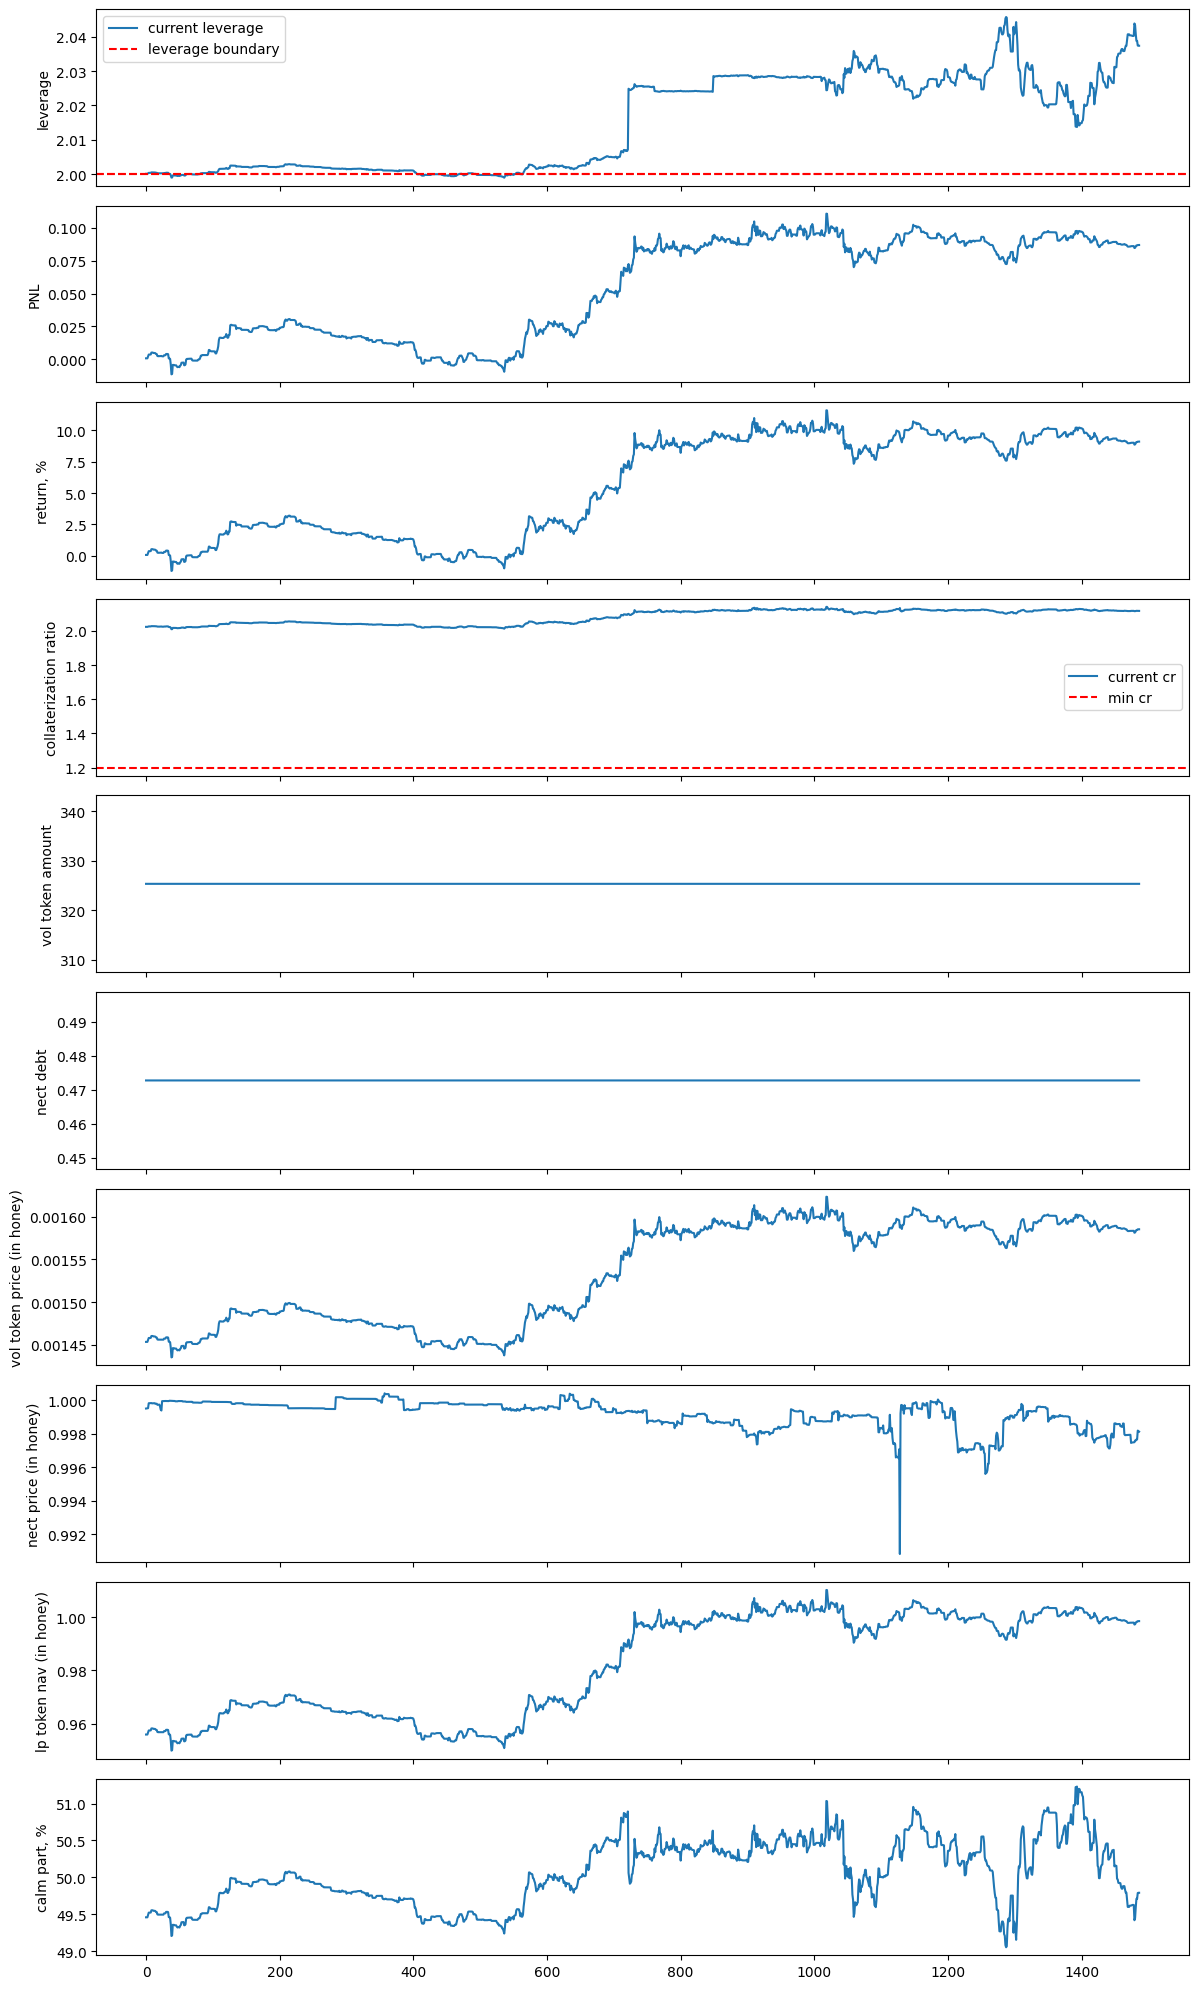

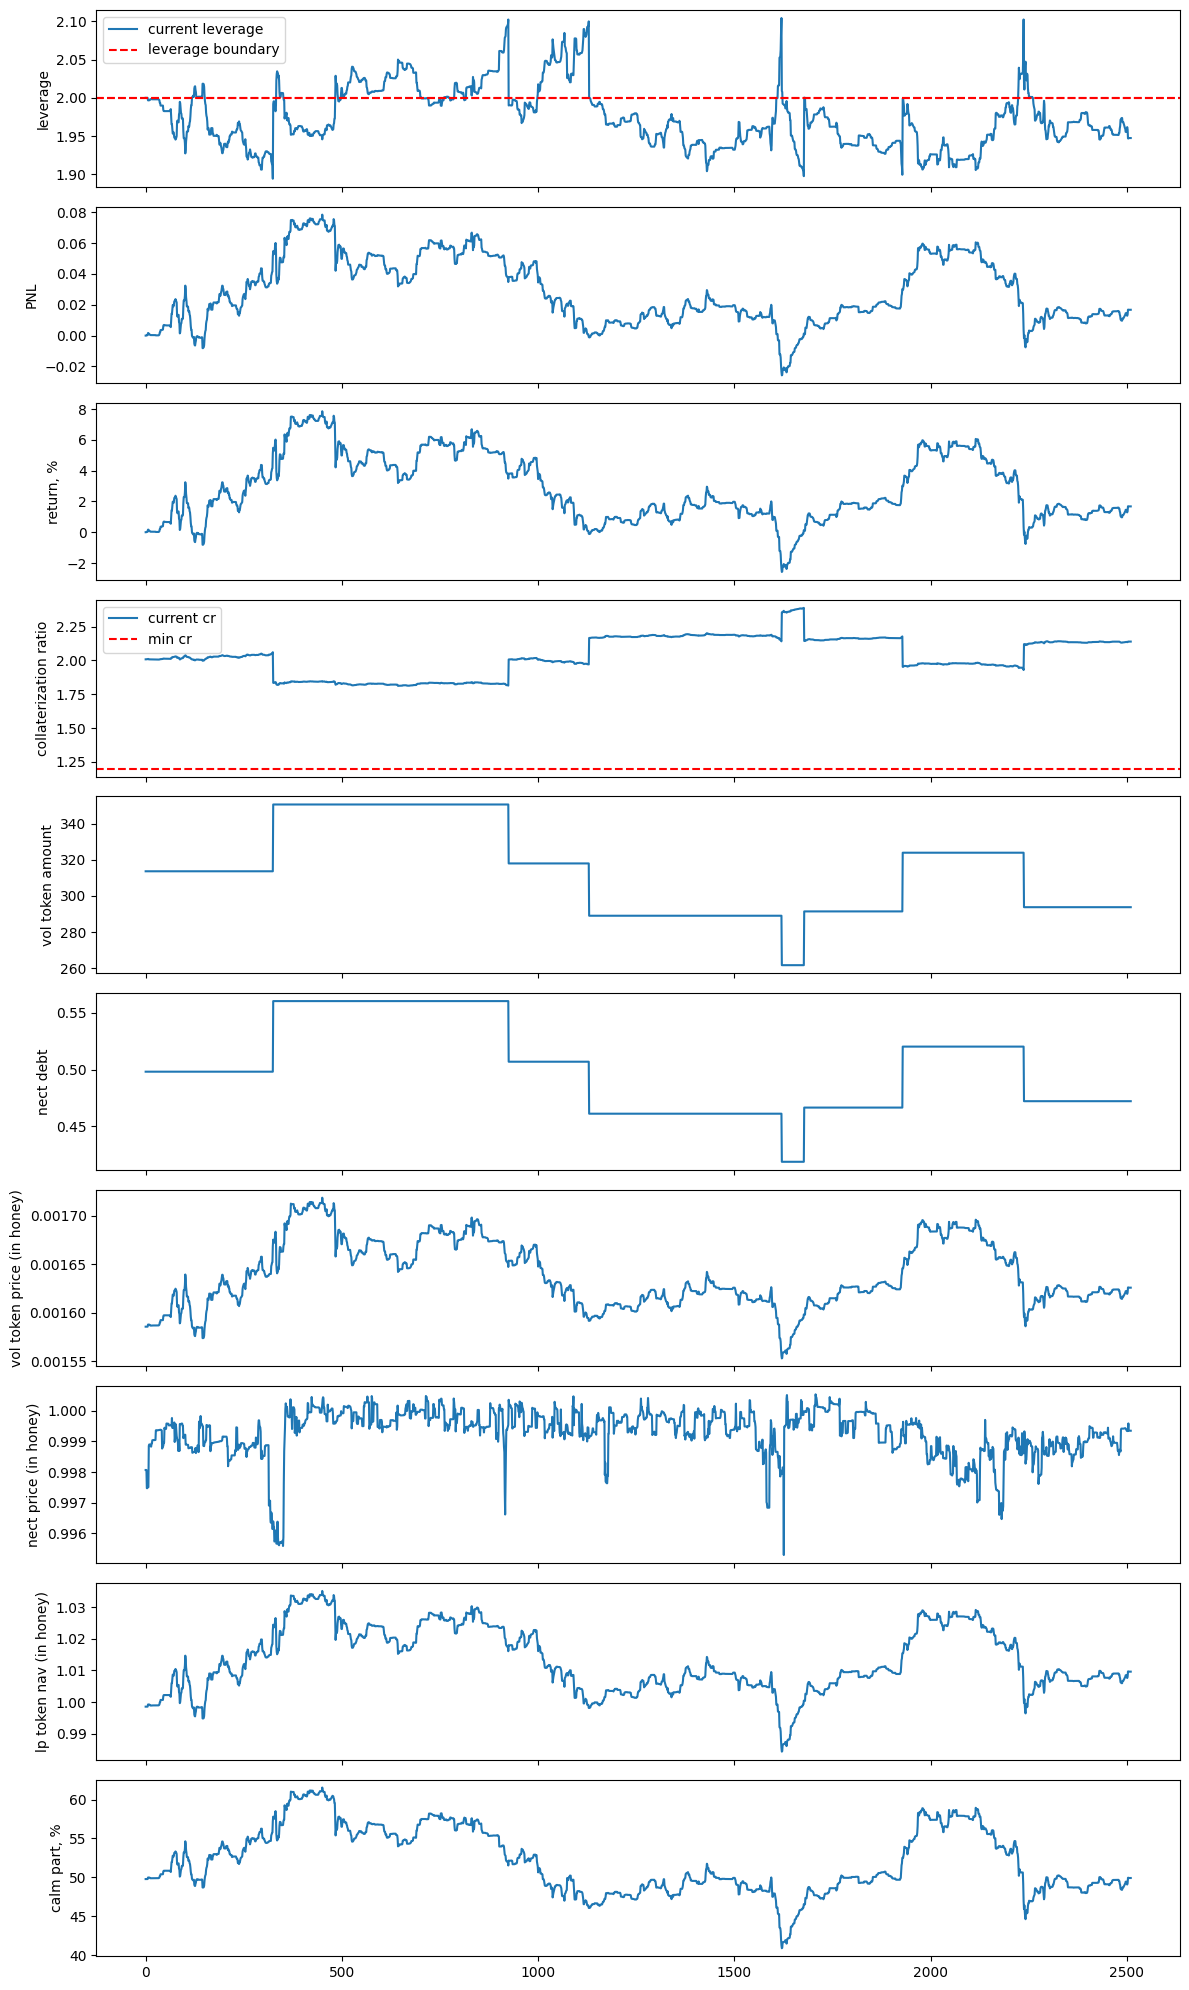

In [4]:
eval_env_calm = agentDLVEnvV1(
    nect_honey_price = nect_price_calm_test, 
    LP_nav_honey = nav_calm_test, 
    vol_token_price=vol_token_price_calm_test,
    volatile_part = volatile_part_calm_test,
    target_leverage=TARGET_LEVERAGE
)

obs, _ = eval_env_calm.reset()
done = False
while not done:
    action = naiveAgent(obs, deviation=0.05)
    obs, reward, _, done, infos = eval_env_calm.step(action)

history_economics = infos['episode_economics']
plot_economic_metrics(history_economics, TARGET_LEVERAGE, TARGET_LEVERAGE)

eval_env_vol = agentDLVEnvV1(
    nect_honey_price = nect_price_vol_test, 
    LP_nav_honey = nav_vol_test, 
    volatile_part = volatile_part_vol_test,
    vol_token_price=vol_token_price_vol_test,
    target_leverage=TARGET_LEVERAGE
)

obs, _ = eval_env_vol.reset()
done = False
while not done:
    action = naiveAgent(obs, deviation=0.05)
    obs, reward, _, done, infos = eval_env_vol.step(action)

history_economics = infos['episode_economics']
plot_economic_metrics(history_economics, TARGET_LEVERAGE, TARGET_LEVERAGE)
